In [1]:
# pip install ipympl

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py
import math

from mpl_toolkits.mplot3d import axes3d
%matplotlib widget

In [2]:
# Nc=4
# Nf=1

In [3]:
Ns=32
Nt=8

In [4]:
# gstar_HSDM = 2*(Nc**2-1)+2*Nf**2
# gstar_SM = 106.75
# gstar = gstar_SM + gstar_HSDM
# Om_HSDM = gstar_HSDM / (gstar_HSDM+gstar_SM)

In [5]:
# MP_GeV = 1.220890 * 10**19 # GeV https://physics.nist.gov/cgi-bin/cuu/Value?plkmc2gev

In [6]:
two_param = False

In [7]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def do_it_wavg( self, avg ):
        self.est = avg

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jk_avg(i, binsize, np_data):
    return np_data[i]

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

class Jackknife2:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.cov_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.cov_est += np.kron( self.jack_avg[i] - self.est, self.jack_avg[i] - self.est )
        self.cov_est /= self.nbins
        self.cov_est *= self.nbins -1
        self.cov_est = self.cov_est.reshape( self.est.shape[0], self.est.shape[0] )

    def do_it_wavg( self, avg ):
        # for i in range( 0, self.nbins ):
        #     self.est += self.jack_avg[i]
        # self.est /= self.nbins
        self.est = avg

        for i in range( 0, self.nbins ):
            self.cov_est += np.kron( self.jack_avg[i] - self.est, self.jack_avg[i] - self.est )
        self.cov_est /= self.nbins
        self.cov_est *= self.nbins -1
        self.cov_est = self.cov_est.reshape( self.est.shape[0], self.est.shape[0] )

    def mean( self ):
        return self.est

    def cov( self ):
        return self.cov_est

    def err( self ):
        return np.sqrt(self.cov_est.diagonal())

In [8]:
font = {'size'   : 12}

colors={
    2:'#006BA4',
    3:'#FF800E',
    4:'#ABABAB',
    "A":'#FFBC79',
    "B":'#5F9ED1',
    "C":'#C85200',
    6:'#898989',
    7:'#A2C8EC',
    8:'#595959',
    9:'#CFCFCF'
}

markers={
    2:"o", 
    3:"d", 
    4:"v", 
    "A":"x", 
    "B":"<", 
    "C":"^", 
}

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 22
})

In [9]:
pwd

'/mnt/hdd_barracuda/llnl/reweight/32c_reanalysis/alpha_beta'

In [10]:
nbetasMeas=1000

In [11]:
# v16 32c windows. S3 window (window0Xn) = the SHOT jk keeplist nodes (m0.4 non-contiguous: gaps
# 767/769/771/774/776); loaded from the clean-room keeplist. DeltaV window (window0X) =
# arange(keeplist_start, ibetac) -- full supercooled range up to Tc (Veff.h5 has all keys; DeltaV->0
# at ibetac, flips beyond -> do NOT trespass ibetac).
ibetac02 = int(np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass0p2000_"+str(Ns)+".dat" )[1])
window02n = np.loadtxt( "../spline_cpp_v16_32c_claude/keeplist_v16_m0p2000_claude.dat" )[:,0].astype(int)
window02 = np.arange( int(window02n[0]), ibetac02 )

ibetac03 = int(np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass0p3000_"+str(Ns)+".dat" )[1])
window03n = np.loadtxt( "../spline_cpp_v16_32c_claude/keeplist_v16_m0p3000_claude.dat" )[:,0].astype(int)
window03 = np.arange( int(window03n[0]), ibetac03 )

ibetac04 = int(np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass0p4000_"+str(Ns)+".dat" )[1])
window04n = np.loadtxt( "../spline_cpp_v16_32c_claude/keeplist_v16_m0p4000_claude.dat" )[:,0].astype(int)
window04 = np.arange( int(window04n[0]), ibetac04 )

In [12]:
ibetac0s = {
    "0p2000": ibetac02,
    "0p3000": ibetac03,
    "0p4000": ibetac04
}

In [13]:
windows = {
    "0p2000": window02,
    "0p3000": window03,
    "0p4000": window04
}

In [14]:
windows2 = {
    "0p2000": window02n,
    "0p3000": window03n,
    "0p4000": window04n
}

In [15]:
nbetas = {
    '0p2000':9,
    '0p3000':8,
    '0p4000':9
}
nbins=40

In [16]:
# @@@@ TODO: CHECK FIT WITH PLOTS

In [17]:
epsilon=0.5
GAM = 2.500 # 3.127   # 3D Ising (6nu-2beta); systematic variation 2.50 (3D tricritical). See gamma_scaling_estimate_claude.md
gamtag = ("c2only_gam%.3f" % GAM).replace('.', 'p').replace('-', 'm')


In [18]:
from f import F_ainv
from f import F_MB
from f import F_TmTc

In [19]:
f_ainv = F_ainv( epsilon )
f_MB = F_MB( epsilon )
f_TmTc = F_TmTc( Nt, epsilon )

In [20]:
# eps=1.0
# eps=0.01
# eps=0.001
# eps=0.0001
# eps=0.00001
# eps=0.

In [21]:
# def eps_trick(orig, eps):
#     mn = np.mean(orig, axis=0)
#     dev = orig-mn
#     scaled = mn + dev * eps
#     return scaled

In [22]:
# def eps_trick2(orig, eps, mean):
#     mn = np.mean(orig, axis=0)
#     dev = orig-mn
#     scaled = mn + dev * eps
#     return scaled

# Tc

In [23]:
# def Tc_MB_fitter( MB, b0, b1, b2 ):
#     return b0 + b1*MB + b2*MB**2

# def dTc_dMB_fitter( MB, b0, b1, b2 ):
#     return b1 + 2.0*b2*MB

def Tc_MB_fitter( MB, b0, b1 ):
    return b0 + b1*MB

def dTc_dMB_fitter( MB, b0, b1 ):
    return b1

In [24]:
mass="0p2000"
betac_ibetac_m02 = np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass"+mass+"_"+str(Ns)+".dat" )
mass="0p3000"
betac_ibetac_m03 = np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass"+mass+"_"+str(Ns)+".dat" )
mass="0p4000"
betac_ibetac_m04 = np.loadtxt( "../spline_cpp_v16_32c_claude/betac_ibetac_mass"+mass+"_"+str(Ns)+".dat" )

Tc_m0p2000 = f_ainv(betac_ibetac_m02[0], 0.2)/Nt
Tc_m0p3000 = f_ainv(betac_ibetac_m03[0], 0.3)/Nt
Tc_m0p4000 = f_ainv(betac_ibetac_m04[0], 0.4)/Nt

MB_m0p2000 = f_MB(betac_ibetac_m02[0], 0.2)
MB_m0p3000 = f_MB(betac_ibetac_m03[0], 0.3)
MB_m0p4000 = f_MB(betac_ibetac_m04[0], 0.4)

In [25]:
mass="0p2000"

betas = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" )

betacs_jk = np.array([[betas[ int(ibetacs_jk[jdrop][ibin]) ] for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
Tc_jkdatas_m0p2000 = np.array([[ f_ainv( betacs_jk[jdrop][ibin], 0.2)/Nt for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
MB_jkdatas_m0p2000 = np.array([[ f_MB( betacs_jk[jdrop][ibin], 0.2) for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])

In [26]:
mass="0p3000"

betas = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" )

betacs_jk = np.array([[betas[ int(ibetacs_jk[jdrop][ibin]) ] for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
Tc_jkdatas_m0p3000 = np.array([[ f_ainv( betacs_jk[jdrop][ibin], 0.3)/Nt for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
MB_jkdatas_m0p3000 = np.array([[ f_MB( betacs_jk[jdrop][ibin], 0.3) for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])

In [27]:
mass="0p4000"

betas = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" )

betacs_jk = np.array([[betas[ int(ibetacs_jk[jdrop][ibin]) ] for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
Tc_jkdatas_m0p4000 = np.array([[ f_ainv( betacs_jk[jdrop][ibin], 0.4)/Nt for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])
MB_jkdatas_m0p4000 = np.array([[ f_MB( betacs_jk[jdrop][ibin], 0.4) for ibin in np.arange(nbins) ] for jdrop in np.arange(nbetas[mass]) ])

In [28]:
mass="0p2000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    Tc_jkresamp = Tc_jkdatas_m0p2000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, Tc_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( Tc_m0p2000 )
    err_sq += jk.err()**2
    
delta_Tc_m0p2000 = np.sqrt(err_sq)

In [29]:
mass="0p3000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    Tc_jkresamp = Tc_jkdatas_m0p3000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, Tc_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( Tc_m0p3000 )
    err_sq += jk.err()**2
    
delta_Tc_m0p3000 = np.sqrt(err_sq)

In [30]:
mass="0p4000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    Tc_jkresamp = Tc_jkdatas_m0p4000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, Tc_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( Tc_m0p4000 )
    err_sq += jk.err()**2
    
delta_Tc_m0p4000 = np.sqrt(err_sq)

In [31]:
delta_Tcs = np.array([delta_Tc_m0p2000, delta_Tc_m0p3000, delta_Tc_m0p4000])

In [32]:
mass="0p2000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    MB_jkresamp = MB_jkdatas_m0p2000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, MB_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( MB_m0p2000 )
    err_sq += jk.err()**2
    
delta_MB_m0p2000 = np.sqrt(err_sq)

In [33]:
mass="0p3000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    MB_jkresamp = MB_jkdatas_m0p3000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, MB_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( MB_m0p3000 )
    err_sq += jk.err()**2
    
delta_MB_m0p3000 = np.sqrt(err_sq)

In [34]:
mass="0p4000"

err_sq = 0.0
for jdrop in np.arange(nbetas[mass]):
    MB_jkresamp = MB_jkdatas_m0p4000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, MB_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( MB_m0p4000 )
    err_sq += jk.err()**2
    
delta_MB_m0p4000 = np.sqrt(err_sq)

In [35]:
delta_MBs = np.array([delta_MB_m0p2000, delta_MB_m0p3000, delta_MB_m0p4000])

In [36]:
# fitparams0 = np.array([ 1.210107337539255146e-01, 1.415778904537491438e-02, -5.120170917404638861e-04 ])
fitparams0 = np.array([ 1.210107337539255146e-01, 1.415778904537491438e-02 ])

In [37]:
Tcs = np.array([Tc_m0p2000, Tc_m0p3000, Tc_m0p4000])
MBs = np.array([MB_m0p2000, MB_m0p3000, MB_m0p4000])

fitparams = fitparams0
for i in range(10):
    d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1] )
    sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
    opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
                                 sigma=sigma,
                              p0=fitparams,
                               full_output=True,
                               absolute_sigma=True)
    fitparams = opt[0]
# for i in range(10):
#     d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1], fitparams[2] )
#     sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
#     opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
#                                  sigma=sigma,
#                               p0=fitparams,
#                                full_output=True,
#                                absolute_sigma=True)

    fitparams = opt[0]
Tcparams=opt[0]

In [38]:
sigma

array([9.30173963e-05, 9.90586182e-05, 1.05710993e-04])

In [39]:
fitparams

array([0.125033  , 0.01135522])

In [40]:
Tcparams

array([0.125033  , 0.01135522])

In [41]:
MBs

array([2.34746502, 3.08556939, 3.85062229])

In [42]:
Tcs

array([0.1515937 , 0.16028259, 0.16863894])

In [43]:
Tc_MB_fitter(MBs, fitparams[0], fitparams[1])

array([0.15168897, 0.16007031, 0.16875765])

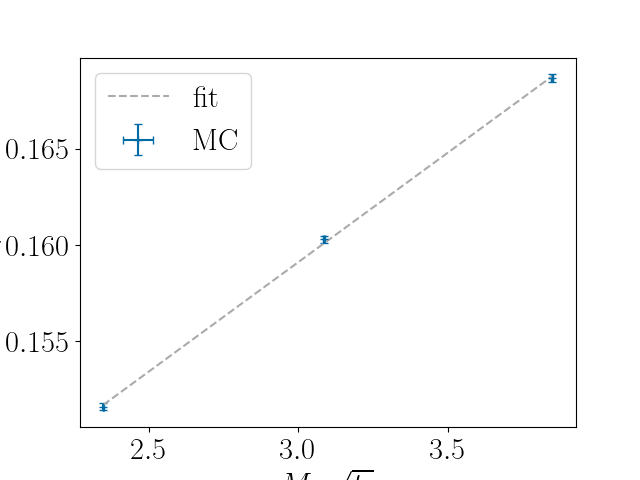

In [44]:
# yyyy = Tc_MB_fitter(MBs, fitparams[0], fitparams[1], fitparams[2])
yyyy = Tc_MB_fitter(MBs, fitparams[0], fitparams[1] )
plt.clf()
plt.errorbar( MBs, Tcs, 
              yerr=delta_Tcs/epsilon, 
              xerr=delta_MBs/epsilon, 
              ls='none', capsize=3,
            c=colors[2], marker='+', label="${\\rm MC}$" )
plt.plot( MBs, yyyy, c=colors[4], ls='dashed', label='${\\rm fit}$' )
plt.xlabel("$M_B \\sqrt{t_0}$")
plt.ylabel("$T_c \\sqrt{t_0}$")
plt.legend()
plt.savefig("Tc_MB_"+gamtag+".pdf", bbox_inches='tight')
plt.show()

In [45]:
yyyy = Tc_MB_fitter(MBs, fitparams[0], fitparams[1])
np.sum( (Tcs-yyyy)**2/sigma**2 )/(len(Tcs)-2)*epsilon

np.float64(3.451256389743881)

In [46]:
# yyyy = Tc_MB_fitter(MBs, fitparams[0], fitparams[1])
# np.sum( (Tcs-yyyy)**2/sigma**2 )/(len(Tcs)-3)*epsilon

In [47]:
# vary m=0.2
mass="0p2000"
jk_Tcparams_m0p2000=[]

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    
    # Tc_jkresamp = eps_trick(Tc_jkdatas_m0p2000[jdrop], eps)
    # MB_jkresamp = eps_trick(MB_jkdatas_m0p2000[jdrop], eps)
    Tc_jkresamp = Tc_jkdatas_m0p2000[jdrop]
    MB_jkresamp = MB_jkdatas_m0p2000[jdrop]
    for ibin in np.arange(nbins):
        Tcs = np.array([Tc_jkresamp[ibin], Tc_m0p3000, Tc_m0p4000])
        MBs = np.array([MB_jkresamp[ibin], MB_m0p3000, MB_m0p4000])

        fitparams = fitparams0
        for i in range(10):
            d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1] )
            sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
                                         sigma=sigma,
                                      p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            # d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1], fitparams[2] )
            # sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            # opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
            #                              sigma=sigma,
            #                           p0=fitparams,
            #                            full_output=True,
            #                            absolute_sigma=True)
        
            fitparams = opt[0]
        fp_jk_.append( opt[0] )

    jk_data = np.array(fp_jk_)
    jk_Tcparams_m0p2000.append( jk_data )

In [48]:
# vary m=0.3
mass="0p3000"
jk_Tcparams_m0p3000=[]

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    
    # Tc_jkresamp = eps_trick(Tc_jkdatas_m0p3000[jdrop], eps)
    # MB_jkresamp = eps_trick(MB_jkdatas_m0p3000[jdrop], eps)
    Tc_jkresamp = Tc_jkdatas_m0p3000[jdrop]
    MB_jkresamp = MB_jkdatas_m0p3000[jdrop]
    for ibin in np.arange(nbins):
        Tcs = np.array([Tc_m0p2000, Tc_jkresamp[ibin], Tc_m0p4000])
        MBs = np.array([MB_m0p2000, MB_jkresamp[ibin], MB_m0p4000])

        fitparams = fitparams0
        for i in range(10):
            d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1] )
            sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
                                         sigma=sigma,
                                      p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            # d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1], fitparams[2] )
            # sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            # opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
            #                              sigma=sigma,
            #                           p0=fitparams,
            #                            full_output=True,
            #                            absolute_sigma=True)

        
            fitparams = opt[0]
        fp_jk_.append( opt[0] )

    jk_data = np.array(fp_jk_)
    jk_Tcparams_m0p3000.append( jk_data )

In [49]:
# vary m=0.4
mass="0p4000"
jk_Tcparams_m0p4000=[]

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    
    # Tc_jkresamp = eps_trick(Tc_jkdatas_m0p4000[jdrop], eps)
    # MB_jkresamp = eps_trick(MB_jkdatas_m0p4000[jdrop], eps)
    Tc_jkresamp = Tc_jkdatas_m0p4000[jdrop]
    MB_jkresamp = MB_jkdatas_m0p4000[jdrop]  
    for ibin in np.arange(nbins):
        Tcs = np.array([Tc_m0p2000, Tc_m0p3000, Tc_jkresamp[ibin]])
        MBs = np.array([MB_m0p2000, MB_m0p3000, MB_jkresamp[ibin]])

        fitparams = fitparams0
        for i in range(10):
            d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1] )
            sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
                                         sigma=sigma,
                                      p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            # d0s = dTc_dMB_fitter( MBs, fitparams[0], fitparams[1], fitparams[2] )
            # sigma = np.sqrt( delta_Tcs**2 + d0s**2 * delta_MBs**2)
            # opt = sp.optimize.curve_fit( f=Tc_MB_fitter, xdata=MBs, ydata=Tcs, 
            #                              sigma=sigma,
            #                           p0=fitparams,
            #                            full_output=True,
            #                            absolute_sigma=True)

        
            fitparams = opt[0]
        fp_jk_.append( opt[0] )

    jk_data = np.array(fp_jk_)
    jk_Tcparams_m0p4000.append( jk_data )

In [50]:
# class F_Tc:
#     def fitter( self, MB, b0, b1, b2 ):
#         return b0 + b1*MB + b2*MB**2

#     def __init__( self, fp, epsilon ):
#         self.fp = fp

#     def __call__( self, MB ):
#         return self.fitter( MB, self.fp[0], self.fp[1], self.fp[2] )

In [51]:
# class F_Tc:
#     def fitter( self, MB, b0, b1, b2 ):
#         return b0 + b1*MB # + b2*MB**2

#     def __init__( self, fp, epsilon ):
#         self.fp = fp

#     def __call__( self, MB ):
#         return self.fitter( MB, self.fp[0], self.fp[1] )

In [52]:
# def Tc_MB_fitter( MB, b0, b1, b2 ):
#     return b0 + b1*MB + b2*MB**2

# def dTc_dMB_fitter( MB, b0, b1, b2 ):
#     return b1 + 2.0*b2*MB

# S3

In [53]:
def S3hat_fitter(TmTc_MB, Mc, c0, c1, c2, gam ):
    TmTc = TmTc_MB[0]
    MB = TmTc_MB[1]
    return (MB-Mc)**gam  * ( c0 + c1/TmTc + c2/TmTc**2 )

def d0_S3hat_fitter(TmTc_MB, Mc, c0, c1, c2, gam ):
    TmTc = TmTc_MB[0]
    MB = TmTc_MB[1]
    return (MB-Mc)**gam  * ( -1.0*c1/TmTc**2 -2.0 * c2/TmTc**3 )

def d1_S3hat_fitter(TmTc_MB, Mc, c0, c1, c2, gam ):
    TmTc = TmTc_MB[0]
    MB = TmTc_MB[1]
    return gam*(MB-Mc)**(gam-1.0)  * ( c0 + c1/TmTc + c2/TmTc**2 )

In [54]:
pwd

'/mnt/hdd_barracuda/llnl/reweight/32c_reanalysis/alpha_beta'

In [55]:
mass="0p2000"

S3hats_=[]
for ibeta in windows2[mass]:
    h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"/S3_"+str(ibeta)+".h5", 
              'r')
    tmp = h['Scl'][()]
    S3hats_.append(tmp)
    h.close()
S3hats_m0p2000 = np.array(S3hats_)

# err_sq = 0.0*windows2[mass]
S3hats_jkdatas_m0p2000 = []
for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        S3hats_ = []
        for ibeta in windows2[mass]:
            print(jdrop, ibin, ibeta)
            h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"_jk_"+str(jdrop)+"_"+str(nbins)+"_"+str(ibin)+"/S3_"+str(ibeta)+".h5", 
                          'r')
            tmp = h[str(ibeta)+'/Scl'][()]
            h.close()
            # tmp = np.loadtxt("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"_jk_"+str(jdrop)+"_40_"+str(ibin)+"/Scl_"+str(ibeta)+".dat")
            S3hats_.append(tmp)
        
        S3hats = np.array(S3hats_)
        jk_data_.append( S3hats )
    jk_data = np.array( jk_data_ )
    S3hats_jkdatas_m0p2000.append( jk_data )

0 0 763
0 0 764
0 0 765
0 0 766
0 0 767
0 0 768
0 0 769
0 0 770
0 0 771
0 0 772
0 0 773
0 0 774
0 0 775
0 0 776
0 0 777
0 0 778
0 0 779
0 0 780
0 0 781
0 0 782
0 0 783
0 0 784
0 0 785
0 0 786
0 0 787
0 0 788
0 0 789
0 1 763
0 1 764
0 1 765
0 1 766
0 1 767
0 1 768
0 1 769
0 1 770
0 1 771
0 1 772
0 1 773
0 1 774
0 1 775
0 1 776
0 1 777
0 1 778
0 1 779
0 1 780
0 1 781
0 1 782
0 1 783
0 1 784
0 1 785
0 1 786
0 1 787
0 1 788
0 1 789
0 2 763
0 2 764
0 2 765
0 2 766
0 2 767
0 2 768
0 2 769
0 2 770
0 2 771
0 2 772
0 2 773
0 2 774
0 2 775
0 2 776
0 2 777
0 2 778
0 2 779
0 2 780
0 2 781
0 2 782
0 2 783
0 2 784
0 2 785
0 2 786
0 2 787
0 2 788
0 2 789
0 3 763
0 3 764
0 3 765
0 3 766
0 3 767
0 3 768
0 3 769
0 3 770
0 3 771
0 3 772
0 3 773
0 3 774
0 3 775
0 3 776
0 3 777
0 3 778
0 3 779
0 3 780
0 3 781
0 3 782
0 3 783
0 3 784
0 3 785
0 3 786
0 3 787
0 3 788
0 3 789
0 4 763
0 4 764
0 4 765
0 4 766
0 4 767
0 4 768
0 4 769
0 4 770
0 4 771
0 4 772
0 4 773
0 4 774
0 4 775
0 4 776
0 4 777
0 4 778
0 4 779


In [56]:
mass="0p3000"

S3hats_=[]
for ibeta in windows2[mass]:
    h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"/S3_"+str(ibeta)+".h5", 
              'r')
    tmp = h['Scl'][()]
    S3hats_.append(tmp)
    h.close()
S3hats_m0p3000 = np.array(S3hats_)

# err_sq = 0.0*windows2[mass]
S3hats_jkdatas_m0p3000 = []
for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        print( jdrop, ibin )
        S3hats_ = []
        for ibeta in windows2[mass]: 
            h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"_jk_"+str(jdrop)+"_"+str(nbins)+"_"+str(ibin)+"/S3_"+str(ibeta)+".h5", 
                          'r')
            tmp = h[str(ibeta)+'/Scl'][()]
            h.close()
            S3hats_.append(tmp)
        
        S3hats = np.array(S3hats_)
        jk_data_.append( S3hats )
    jk_data = np.array( jk_data_ )
    S3hats_jkdatas_m0p3000.append( jk_data )

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
2 21
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
2 30
2 31
2 32
2 33
2 34
2 35
2 36
2 37
2 38
2 39
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27
3 28
3 29
3 30
3 31
3 32
3 33
3 34
3 35
3 36
3 37
3 38
3 39
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
4 21
4 22
4 23
4 24
4 25
4 26
4 27
4 28
4 29
4 30
4 31
4 32
4 33
4 34
4 35
4 36
4 37
4 38
4 39
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11


In [57]:
mass="0p4000"

S3hats_=[]
for ibeta in windows2[mass]:
    h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"/S3_"+str(ibeta)+".h5", 
              'r')
    tmp = h['Scl'][()]
    S3hats_.append(tmp)
    h.close()
S3hats_m0p4000 = np.array(S3hats_)

# err_sq = 0.0*windows2[mass]
S3hats_jkdatas_m0p4000 = []
for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        print( jdrop, ibin )
        S3hats_ = []
        for ibeta in windows2[mass]:
            h = h5py.File("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"_jk_"+str(jdrop)+"_"+str(nbins)+"_"+str(ibin)+"/S3_"+str(ibeta)+".h5", 
                          'r')
            tmp = h[str(ibeta)+'/Scl'][()]
            h.close()
            S3hats_.append(tmp)
        
        S3hats = np.array(S3hats_)
        jk_data_.append( S3hats )
    jk_data = np.array( jk_data_ )
    S3hats_jkdatas_m0p4000.append( jk_data )

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
2 21
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
2 30
2 31
2 32
2 33
2 34
2 35
2 36
2 37
2 38
2 39
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27
3 28
3 29
3 30
3 31
3 32
3 33
3 34
3 35
3 36
3 37
3 38
3 39
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
4 21
4 22
4 23
4 24
4 25
4 26
4 27
4 28
4 29
4 30
4 31
4 32
4 33
4 34
4 35
4 36
4 37
4 38
4 39
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11


In [58]:
x_dx_y_dy = []

# 0p2
mq = 0.2
mass="0p2000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows2[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )


# 0p3
mq = 0.3
mass="0p3000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows2[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )


# 0p4
mq = 0.4
mass="0p4000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows2[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )

In [59]:
len(x_dx_y_dy)

3

In [60]:
mass="0p2000"

chk=[]

err_sq = 0.0*windows2[mass]
for jdrop in np.arange(nbetas[mass]):
    S3hats_jkresamp = S3hats_jkdatas_m0p2000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, S3hats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( S3hats_m0p2000 )
    err_sq += jk.err()**2
    chk.append(jk.mean())
    
delta_S3hats_m0p2000 = np.sqrt(err_sq)

In [61]:
mass="0p3000"

err_sq = 0.0*windows2[mass]
for jdrop in np.arange(nbetas[mass]):
    S3hats_jkresamp = S3hats_jkdatas_m0p3000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, S3hats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( S3hats_m0p3000 )
    err_sq += jk.err()**2

delta_S3hats_m0p3000 = np.sqrt(err_sq)

In [62]:
mass="0p4000"

chk=[]

err_sq = 0.0*windows2[mass]
for jdrop in np.arange(nbetas[mass]):
    S3hats_jkresamp = S3hats_jkdatas_m0p4000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, S3hats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( S3hats_m0p4000 )
    err_sq += jk.err()**2
    chk.append(jk.mean())

delta_S3hats_m0p4000 = np.sqrt(err_sq)

In [63]:
# plt.clf()
# for i in range(9):
#     plt.plot( windows2[mass], np.array(chk)[i], label=str(i), ls='none', marker='o' )

# plt.legend()
# plt.show()

In [64]:
# plt.clf()
# for i in range(5,9):
#     plt.plot( windows2[mass], np.array(chk)[i], label=str(i) )

# plt.legend()
# plt.show()

In [65]:
# plt.clf()
# for i in range(3,6):
#     plt.plot( windows2[mass], np.array(chk)[i], label=str(i) )

# plt.legend()
# plt.show()

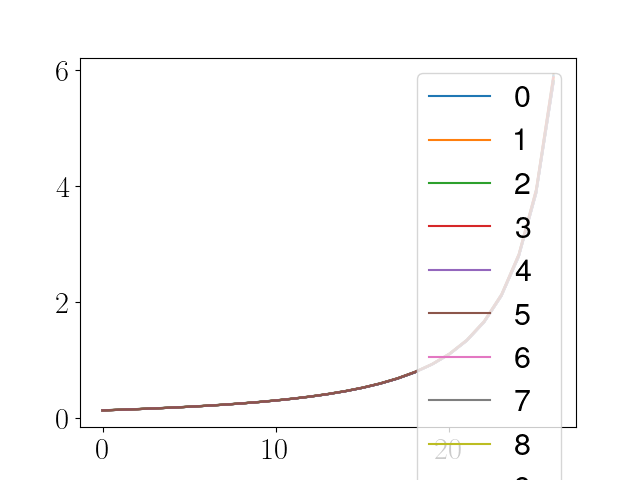

In [66]:
tmp=S3hats_jkdatas_m0p2000[2]
plt.clf()
for ibin in range(0,16):
    plt.plot( tmp[ibin], label=str(ibin) )

plt.legend()
plt.show()

In [67]:
windows2[mass].shape

(26,)

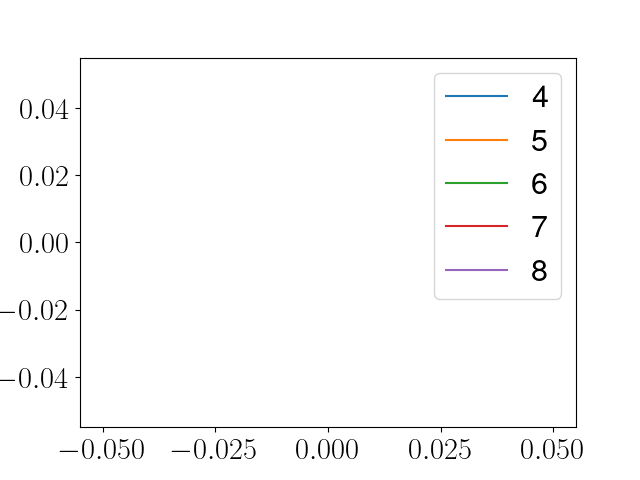

In [68]:
plt.clf()
mm=29
for i in range(4,nbetas[mass]):
    plt.plot( windows2[mass][mm:], np.array(chk)[i][mm:], label=str(i) )

plt.legend()
plt.show()

In [69]:
# basedir = "../spline_cpp_v16_32c_claude/"

In [70]:
# nbeta=nbetas[mass]

In [71]:
# betac_ibetac=np.loadtxt(basedir+"/betac_ibetac_mass"+mass+"_"+str(Ns)+".dat")
# ibetac_jk=np.loadtxt(basedir+"/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat")

In [72]:
# tmp=[]

# for jdrop in range(nbeta):
#     for ibin in range(nbins):
#         i=int(ibetac_jk[jdrop][ibin])
#         minima_data_=np.loadtxt(basedir+"/fit_params_"+str(Ns)+"c_m"+mass+"_jk_"+str(jdrop)+"_40_"+str(ibin)+"/minima_data_"+str(i)+".dat")
#         tmp.append(minima_data_)

In [73]:
# plt.clf()
# plt.plot( np.array(tmp).T[1])
# plt.legend()
# plt.show()

In [74]:
fitparams

array([0.125033  , 0.01135522])

In [75]:
def S3hat_c2only( TmTc_MB, Mc, c2 ):
    return S3hat_fitter( TmTc_MB, Mc, 0.0, 0.0, c2, GAM )   # pure thin-wall: c0=c1=0

fitparams0 = [2.13, 0.0, 0.0, 3.0e-06, GAM]   # c2-only: fit [Mc,c2]; slots c0,c1 held at 0


In [76]:
# k1=20
# k2=18 # 15
# k3=20

k1=20
k2=18 # 15
k3=26

In [77]:
mass='0p2000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows2[mass]][-k1:]

array([10.9685 , 10.96855, 10.9686 , 10.96865, 10.9687 , 10.96875,
       10.9688 , 10.96885, 10.9689 , 10.96895, 10.969  , 10.96905,
       10.9691 , 10.96915, 10.9692 , 10.96925, 10.9693 , 10.96935,
       10.9694 , 10.96945])

In [78]:
mass='0p3000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows2[mass]][-k2:]

array([11.01805, 11.0181 , 11.01815, 11.0182 , 11.01825, 11.0183 ,
       11.01835, 11.0184 , 11.01845, 11.0185 , 11.01855, 11.0186 ,
       11.01865, 11.0187 , 11.01875, 11.0188 , 11.01885, 11.0189 ])

In [79]:
mass='0p4000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows2[mass]][-k3:]

array([11.03805, 11.0381 , 11.03815, 11.0382 , 11.03825, 11.0383 ,
       11.03835, 11.0384 , 11.03845, 11.0385 , 11.03855, 11.0386 ,
       11.03865, 11.0387 , 11.03875, 11.0388 , 11.03885, 11.0389 ,
       11.03895, 11.039  , 11.03905, 11.0391 , 11.03915, 11.0392 ,
       11.03925, 11.0393 ])

In [80]:
S3hats_m0p4000.shape

(26,)

In [81]:
xs = np.array([])
delta_xs = np.array([])
ys = np.array([])
delta_ys = np.array([])
zs = np.array([])
delta_zs = np.array([])

ks=[k1,k2,k3]
zpool = [ S3hats_m0p2000, S3hats_m0p3000, S3hats_m0p4000]
delta_zpool = [ delta_S3hats_m0p2000, delta_S3hats_m0p3000, delta_S3hats_m0p4000]

counter=0
for row in x_dx_y_dy:
    k=ks[counter]
    xs = np.concatenate( [ xs, row[0][-k:] ] )
    delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
    ys = np.concatenate( [ ys, row[2][-k:] ] )
    delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
    zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
    delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
    counter+=1

fitparams = fitparams0
for i in range(3):
    d0s = d0_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
    d1s = d1_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
    sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
    opt = sp.optimize.curve_fit( f=S3hat_c2only, xdata=[xs,ys], ydata=zs, 
                                 sigma=sigma,
                                  p0=[fitparams[0], fitparams[3]],
                               full_output=True, 
                               absolute_sigma=True)
    fitparams = [opt[0][0], 0.0, 0.0, opt[0][1], GAM]        
S3params=fitparams

/tmp/ipykernel_2007103/1569400335.py:4: RuntimeWarning: invalid value encountered in power
  return (MB-Mc)**gam  * ( c0 + c1/TmTc + c2/TmTc**2 )


In [82]:
sigma

array([ 0.15112927,  0.16340178,  0.17758249,  0.19404735,  0.21340801,
        0.23638534,  0.26399913,  0.29753408,  0.33906609,  0.39128439,
        0.45833045,  0.54645576,  0.66554589,  0.83189437,  1.07370034,
        1.44245534,  2.04012268,  3.08729726,  5.12367037,  9.71617444,
        3.42193718,  3.66017065,  3.92372655,  4.21611921,  4.54111681,
        4.90359209,  5.30904241,  5.76417234,  6.27693618,  6.85689656,
        7.51578341,  8.26772059,  9.13023538, 10.12497864, 11.27895591,
       12.6264394 , 14.21294249, 16.13685227, 10.97139129, 11.27914829,
       11.59742202, 11.92665218, 12.26738276, 12.62007103, 12.98528752,
       13.36358739, 13.75565165, 14.16201166, 14.58344379, 15.02070839,
       15.47434808, 15.94557102, 16.43501542, 16.94365745, 17.47252605,
       18.02276787, 18.59546491, 19.19203908, 19.81369106, 20.46209541,
       21.13873767, 21.84548288, 22.58420688, 23.35700711])

In [83]:
yyyy = S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )

In [84]:
np.sum( (yyyy-zs)**2/sigma**2 )/( len(yyyy)-5 )*epsilon**2

np.float64(0.28093231957670944)

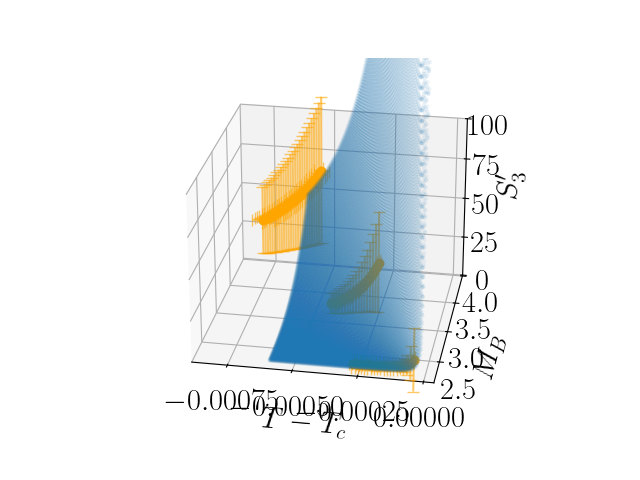

In [86]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.errorbar( xs, ys, zs,
           xerr=delta_xs/epsilon,
           yerr=delta_ys/epsilon,
           zerr=delta_zs/epsilon, ls='none', c='orange', marker='o'
           , zorder=-32, alpha=0.6, capsize=4
           )

# ax.scatter( x1, x2, yy )
# zuplims=yy+dyy
# zlolims=yy-dyy
# estep = 1
# ax.errorbar( x1, x2, yy, 0.01, zuplims=zuplims, zlolims=zlolims, errorevery=estep, ls='none')
# ax.scatter( x1, x2, fit_yy )

xx1 = np.repeat(np.linspace(-0.0006, -0.00002, 200), 200).reshape(200,200)
xx2 = np.repeat(np.linspace(2.3, 3.9, 200), 200).reshape(200,200).T # 2.35, ...
zs2 = S3hat_fitter( [xx1, xx2], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
ax.scatter( xx1, xx2, zs2, alpha=0.05, marker='.' )

ax.plot( xs, ys, zs, ls='none', c='orange', marker='o' )

ax.view_init(elev=25, azim=-80, roll=0)

ax.set_zlim(0,100)
ax.set_xlabel("$T-T_c$")
ax.set_ylabel("$M_B$")
ax.set_zlabel("$S^{\\prime}_3$")

# plt.savefig("S3_"+gamtag+".pdf", bbox_inches='tight')

plt.show()

In [87]:
np.savetxt( "S3_MC_"+gamtag+".dat", np.array([xs, ys, zs, delta_xs/epsilon, delta_ys/epsilon, delta_zs/epsilon]).T )

In [88]:
delta_xs

array([6.95659702e-06, 6.65413628e-06, 6.35167554e-06, 6.04921480e-06,
       5.74675406e-06, 5.44429332e-06, 5.14183258e-06, 4.83937184e-06,
       4.53691110e-06, 4.23445036e-06, 3.93198962e-06, 3.62952888e-06,
       3.32706814e-06, 3.02460740e-06, 2.72214666e-06, 2.41968592e-06,
       2.11722518e-06, 1.81476444e-06, 1.51230370e-06, 1.20984296e-06,
       7.14563977e-06, 6.96241823e-06, 6.77919670e-06, 6.59597517e-06,
       6.41275364e-06, 6.22953210e-06, 6.04631057e-06, 5.86308904e-06,
       5.67986751e-06, 5.49664597e-06, 5.31342444e-06, 5.13020291e-06,
       4.94698138e-06, 4.76375984e-06, 4.58053831e-06, 4.39731678e-06,
       4.21409525e-06, 4.03087371e-06, 2.28774711e-05, 2.25915028e-05,
       2.23055344e-05, 2.20195660e-05, 2.17335976e-05, 2.14476292e-05,
       2.11616608e-05, 2.08756924e-05, 2.05897240e-05, 2.03037556e-05,
       2.00177873e-05, 1.97318189e-05, 1.94458505e-05, 1.91598821e-05,
       1.88739137e-05, 1.85879453e-05, 1.83019769e-05, 1.80160085e-05,
      

In [89]:
# vary m=0.2
jk_S3params_m0p2000=[]
mass="0p2000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # S3hats_jkresamp = eps_trick(S3hats_jkdatas_m0p2000[jdrop], eps)
    S3hats_jkresamp = S3hats_jkdatas_m0p2000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ S3hats_jkresamp[ibin], S3hats_m0p3000, S3hats_m0p4000]
        delta_zpool = [ delta_S3hats_m0p2000, delta_S3hats_m0p3000, delta_S3hats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            d1s = d1_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=S3hat_c2only, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                          p0=[fitparams[0], fitparams[3]],
                                       full_output=True, 
                                       absolute_sigma=True)
            fitparams = [opt[0][0], 0.0, 0.0, opt[0][1], GAM]        
        fp_jk_.append( fitparams )
    
    jk_data = np.array(fp_jk_)
    jk_S3params_m0p2000.append( jk_data )

In [90]:
# vary m=0.3
jk_S3params_m0p3000=[]
mass="0p3000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # S3hats_jkresamp = eps_trick(S3hats_jkdatas_m0p3000[jdrop], eps)
    S3hats_jkresamp = S3hats_jkdatas_m0p3000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ S3hats_m0p2000, S3hats_jkresamp[ibin], S3hats_m0p4000]
        delta_zpool = [ delta_S3hats_m0p2000, delta_S3hats_m0p3000, delta_S3hats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            d1s = d1_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=S3hat_c2only, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                          p0=[fitparams[0], fitparams[3]],
                                       full_output=True, 
                                       absolute_sigma=True)
            fitparams = [opt[0][0], 0.0, 0.0, opt[0][1], GAM]        
        fp_jk_.append( fitparams )
    
    jk_data = np.array(fp_jk_)
    jk_S3params_m0p3000.append( jk_data )

In [91]:
# vary m=0.4
jk_S3params_m0p4000=[]
mass="0p4000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # S3hats_jkresamp = eps_trick(S3hats_jkdatas_m0p4000[jdrop], eps)
    S3hats_jkresamp = S3hats_jkdatas_m0p4000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ S3hats_m0p2000, S3hats_m0p3000, S3hats_jkresamp[ibin] ]
        delta_zpool = [ delta_S3hats_m0p2000, delta_S3hats_m0p3000, delta_S3hats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            d1s = d1_S3hat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3], fitparams[4] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=S3hat_c2only, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                          p0=[fitparams[0], fitparams[3]],
                                       full_output=True, 
                                       absolute_sigma=True)
            fitparams = [opt[0][0], 0.0, 0.0, opt[0][1], GAM]        
        fp_jk_.append( fitparams )
    
    jk_data = np.array(fp_jk_)
    jk_S3params_m0p4000.append( jk_data )

In [92]:
class F_S3hat:
    def fitter(self, TmTc_MB, Mc, c0, c1, c2, gam ):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return (MB-Mc)**gam  * ( c0 + c1/TmTc + c2/TmTc**2 )

    def __init__( self, fp ):
        self.fp = fp

    def __call__( self, TmTc, MB ):
        return self.fitter( [TmTc, MB], self.fp[0], self.fp[1], self.fp[2], self.fp[3], self.fp[4] )

    def dT( self, TmTc, MB ):
        Mc = self.fp[0]
        c0 = self.fp[1]
        c1 = self.fp[2]
        c2 = self.fp[3]
        gam = self.fp[4]
        return (MB-Mc)**gam  * ( -1.0*c1/TmTc**2 -2.0 * c2/TmTc**3 )

# DV

In [93]:
if two_param:
    def DeltaVhat_fitter(TmTc_MB, a0, b0):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return TmTc * ( a0 + b0*MB ) + TmTc**2 * ( a0 + b0*MB )
else:
    def DeltaVhat_fitter(TmTc_MB, a0, b0, c0, d0):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return TmTc * ( a0 + b0*MB ) + TmTc**2 * ( c0 + d0*MB )

    def d0_DeltaVhat_fitter(TmTc_MB, a0, b0, c0, d0):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return ( a0 + b0*MB ) + 2.0*TmTc * ( c0 + d0*MB )

    def d1_DeltaVhat_fitter(TmTc_MB, a0, b0, c0, d0):
        TmTc = TmTc_MB[0]
        MB = TmTc_MB[1]
        return TmTc * ( b0 ) + TmTc**2 * ( d0 )

In [94]:
pwd

'/mnt/hdd_barracuda/llnl/reweight/32c_reanalysis/alpha_beta'

In [95]:
mass="0p2000"

minima = []
directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"/"
f = h5py.File(directory+"/Veff.h5", 'r')
for ibeta in np.arange(nbetasMeas):
    # desc = "jk_"+str(jdrop)+"_40_"+str(ibin)
    tmp = f[str(ibeta)+'/minima_data'][()]
    minima.append(tmp)
f.close()

DeltaVhats_ = []
for ibeta in windows[mass]:
    DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
    DeltaVhats_.append( DeltaVhat )
DeltaVhats_m0p2000 = np.array(DeltaVhats_)

# get error for each ibeta (renormalize) from jackknife
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" ) # renorm Tc
 
# err_sq = 0.0*windows2[mass]
DeltaVhats_jkdatas_m0p2000= []

for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        minima = []
        desc = "jk_"+str(jdrop)+"_40_"+str(ibin)
        directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"_"+desc+"/"
        f = h5py.File(directory+"/Veff.h5", 'r')
        for ibeta in np.arange(nbetasMeas):
            tmp = f[str(ibeta)+'/minima_data'][()]
            
            # tmp = np.loadtxt("../spline_cpp_v16_32c_claude/fit_params_32c_m"+mass+"_jk_"+str(jdrop)+"_40_"+str(ibin)+"/minima_data_"+str(ibeta)+".dat")
            minima.append(tmp)
        f.close()
    
        dibeta = int(ibetacs_jk[jdrop][ibin]) - ibetac0s[mass]
    
        DeltaVhats_ = []
        for ibeta in windows[mass] + dibeta:
            DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
            DeltaVhats_.append( DeltaVhat )
        DeltaVhats = np.array(DeltaVhats_)
        jk_data_.append( DeltaVhats )
    jk_data = np.array( jk_data_ )

    DeltaVhats_jkdatas_m0p2000.append( jk_data )

In [96]:
mass="0p3000"

minima = []
directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"/"
f = h5py.File(directory+"/Veff.h5", 'r')
for ibeta in np.arange(nbetasMeas):
    tmp = f[str(ibeta)+'/minima_data'][()]
    minima.append(tmp)
f.close()

DeltaVhats_ = []
for ibeta in windows[mass]:
    DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
    DeltaVhats_.append( DeltaVhat )
DeltaVhats_m0p3000 = np.array(DeltaVhats_)

# get error for each ibeta (renormalize) from jackknife
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" ) # renorm Tc

# err_sq = 0.0*windows2[mass]
DeltaVhats_jkdatas_m0p3000= []

for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        minima = []
        desc = "jk_"+str(jdrop)+"_40_"+str(ibin)
        directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"_"+desc+"/"
        f = h5py.File(directory+"/Veff.h5", 'r')
        for ibeta in np.arange(nbetasMeas):
            tmp = f[str(ibeta)+'/minima_data'][()]
            minima.append(tmp)
        f.close()
    
        dibeta = int(ibetacs_jk[jdrop][ibin]) - ibetac0s[mass]
    
        DeltaVhats_ = []
        for ibeta in windows[mass] + dibeta:
            DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
            DeltaVhats_.append( DeltaVhat )
        DeltaVhats = np.array(DeltaVhats_)
        jk_data_.append( DeltaVhats )
    jk_data = np.array( jk_data_ )

    DeltaVhats_jkdatas_m0p3000.append( jk_data )

In [97]:
mass="0p4000"

minima = []
directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"/"
f = h5py.File(directory+"/Veff.h5", 'r')
for ibeta in np.arange(nbetasMeas):
    tmp = f[str(ibeta)+'/minima_data'][()]
    minima.append(tmp)
f.close()

DeltaVhats_ = []
for ibeta in windows[mass]:
    DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
    DeltaVhats_.append( DeltaVhat )
DeltaVhats_m0p4000 = np.array(DeltaVhats_)

# get error for each ibeta (renormalize) from jackknife
ibetacs_jk = np.loadtxt( "../spline_cpp_v16_32c_claude/ibetac_jk_mass"+mass+"_"+str(Ns)+".dat" ) # renorm Tc

# err_sq = 0.0*windows2[mass]
DeltaVhats_jkdatas_m0p4000= []

for jdrop in np.arange(nbetas[mass]):

    jk_data_ = []
    for ibin in np.arange(nbins):
        # print( jdrop, ibin )
        minima = []
        desc = "jk_"+str(jdrop)+"_40_"+str(ibin)
        directory = "../spline_cpp_v16_32c_claude/fit_params_"+str(Ns)+"c_m"+mass+"_"+desc+"/"
        f = h5py.File(directory+"/Veff.h5", 'r')
        for ibeta in np.arange(nbetasMeas):
            tmp = f[str(ibeta)+'/minima_data'][()]
            minima.append(tmp)
        f.close()
    
        dibeta = int(ibetacs_jk[jdrop][ibin]) - ibetac0s[mass]
    
        DeltaVhats_ = []
        for ibeta in windows[mass] + dibeta:
            DeltaVhat = minima[ibeta][3] - minima[ibeta][2]
            DeltaVhats_.append( DeltaVhat )
        DeltaVhats = np.array(DeltaVhats_)
        jk_data_.append( DeltaVhats )
    jk_data = np.array( jk_data_ )

    DeltaVhats_jkdatas_m0p4000.append( jk_data )

In [98]:
x_dx_y_dy = []

# 0p2
mq = 0.2
mass="0p2000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )


# 0p3
mq = 0.3
mass="0p3000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )


# 0p4
mq = 0.4
mass="0p4000"

betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betac = betas_all[ibetac0s[mass]]
betas = betas_all[windows[mass]]

MBs = f_MB( betas, mq )
DMBs = np.array([f_MB.D( beta, mq ) for beta in betas ])

dbetas = betas - betac
TmTcs = [f_TmTc( dbeta, mq ) for dbeta in dbetas]
DTmTcs = [f_TmTc.D( dbeta, mq ) for dbeta in dbetas]

x_dx_y_dy.append( [ TmTcs, DTmTcs, MBs, DMBs ] )

In [99]:
len(x_dx_y_dy)

3

In [100]:
mass="0p2000"

err_sq = 0.0*windows[mass]
for jdrop in np.arange(nbetas[mass]):
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p2000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, DeltaVhats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( DeltaVhats_m0p2000 )
    err_sq += jk.err()**2
    
delta_DeltaVhats_m0p2000 = np.sqrt(err_sq)

In [101]:
mass="0p3000"

err_sq = 0.0*windows[mass]
for jdrop in np.arange(nbetas[mass]):
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p3000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, DeltaVhats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( DeltaVhats_m0p3000 )
    err_sq += jk.err()**2

delta_DeltaVhats_m0p3000 = np.sqrt(err_sq)

In [102]:
mass="0p4000"

err_sq = 0.0*windows[mass]
for jdrop in np.arange(nbetas[mass]):
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p4000[jdrop]
    
    jk = Jackknife( nbins, 1 )
    jk.set( jk_avg, DeltaVhats_jkresamp )
    
    jk.do_it()
    # jk.do_it_wavg( DeltaVhats_m0p4000 )
    err_sq += jk.err()**2

delta_DeltaVhats_m0p4000 = np.sqrt(err_sq)

In [103]:
if two_param:
    fitparams0=[ 13.7027236, -9.83191225 ]
    k1=40
    k2=25
    k3=30
else:
    fitparams0=[2.23845161e+01, -1.34122960e+01,  3.46978544e+04, -1.26978924e+04]
    k1=40
    k2=38
    k3=44

In [104]:
mass='0p2000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows[mass]][-k1:]

array([10.96815, 10.9682 , 10.96825, 10.9683 , 10.96835, 10.9684 ,
       10.96845, 10.9685 , 10.96855, 10.9686 , 10.96865, 10.9687 ,
       10.96875, 10.9688 , 10.96885, 10.9689 , 10.96895, 10.969  ,
       10.96905, 10.9691 , 10.96915, 10.9692 , 10.96925, 10.9693 ,
       10.96935, 10.9694 , 10.96945, 10.9695 , 10.96955, 10.9696 ])

In [105]:
mass='0p3000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows[mass]][-k2:]

array([11.0181 , 11.01815, 11.0182 , 11.01825, 11.0183 , 11.01835,
       11.0184 , 11.01845, 11.0185 , 11.01855, 11.0186 , 11.01865,
       11.0187 , 11.01875, 11.0188 , 11.01885, 11.0189 , 11.01895,
       11.019  , 11.01905, 11.0191 , 11.01915, 11.0192 , 11.01925,
       11.0193 , 11.01935, 11.0194 , 11.01945, 11.0195 , 11.01955,
       11.0196 , 11.01965, 11.0197 , 11.01975, 11.0198 , 11.01985,
       11.0199 , 11.01995])

In [106]:
mass='0p4000'
betas_all = np.loadtxt( "../spline_cpp_v16_32c_claude/betas_mass"+mass+"_32.dat" )
betas_all[windows[mass]][-k3:]

array([11.03985, 11.0399 , 11.03995, 11.04   , 11.04005, 11.0401 ,
       11.04015, 11.0402 , 11.04025, 11.0403 , 11.04035, 11.0404 ,
       11.04045, 11.0405 , 11.04055, 11.0406 , 11.04065, 11.0407 ,
       11.04075, 11.0408 , 11.04085, 11.0409 , 11.04095, 11.041  ,
       11.04105, 11.0411 , 11.04115, 11.0412 , 11.04125, 11.0413 ,
       11.04135, 11.0414 , 11.04145, 11.0415 , 11.04155, 11.0416 ,
       11.04165, 11.0417 , 11.04175, 11.0418 , 11.04185, 11.0419 ,
       11.04195, 11.042  ])

In [107]:
xs = np.array([])
delta_xs = np.array([])
ys = np.array([])
delta_ys = np.array([])
zs = np.array([])
delta_zs = np.array([])

ks=[k1,k2,k3]
zpool = [ DeltaVhats_m0p2000, DeltaVhats_m0p3000, DeltaVhats_m0p4000]
delta_zpool = [ delta_DeltaVhats_m0p2000, delta_DeltaVhats_m0p3000, delta_DeltaVhats_m0p4000]

counter=0
for row in x_dx_y_dy:
    k=ks[counter]
    xs = np.concatenate( [ xs, row[0][-k:] ] )
    delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
    ys = np.concatenate( [ ys, row[2][-k:] ] )
    delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
    zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
    delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
    counter+=1

fitparams = fitparams0
for i in range(3):
    d0s = d0_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
    d1s = d1_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
    sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
    opt = sp.optimize.curve_fit( f=DeltaVhat_fitter, xdata=[xs,ys], ydata=zs, 
                                 sigma=sigma,
                          p0=fitparams,
                               full_output=True,
                               absolute_sigma=True)
    fitparams = opt[0]        
DeltaVparams=opt[0]

In [108]:
yyyy = DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )

In [109]:
np.sum( (yyyy-zs)**2/sigma**2 )/( len(yyyy)-5 )*epsilon**2

np.float64(0.0021507159131060765)

In [110]:
pwd

'/mnt/hdd_barracuda/llnl/reweight/32c_reanalysis/alpha_beta'

In [111]:
np.savetxt( "DeltaV_MC_"+gamtag+".dat", np.array([xs, ys, zs, delta_xs/epsilon, delta_ys/epsilon, delta_zs/epsilon]).T )

In [112]:
fitparams

array([ 1.86984241e+00, -6.83489712e+00,  2.37578930e+04, -9.30621884e+03])

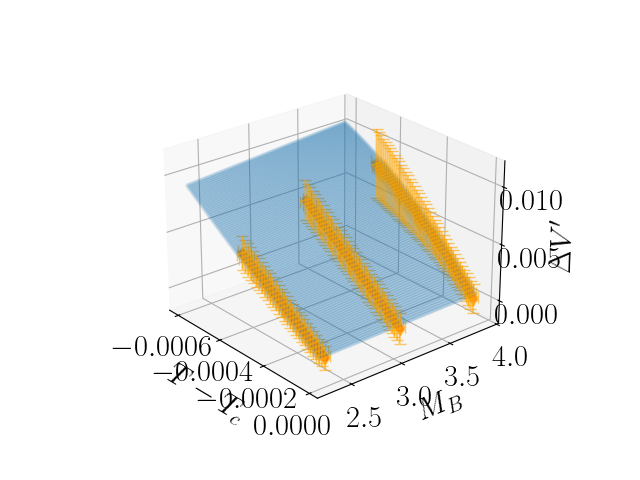

In [113]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.errorbar( xs, ys, zs,
           xerr=delta_xs/epsilon,
           yerr=delta_ys/epsilon,
           zerr=delta_zs/epsilon, ls='none', c='orange', marker='d', 
             zorder=0, alpha=0.6, capsize=4
           )


xx1 = np.repeat(np.linspace(-0.0006, -0.00002, 100), 100).reshape(100,100)
xx2 = np.repeat(np.linspace(2.3, 3.9, 100), 100).reshape(100,100).T
zs2 = DeltaVhat_fitter( [xx1, xx2], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
ax.scatter( xx1, xx2, zs2, alpha=0.1, marker='.'
             )

ax.scatter( xs, ys, zs )

ax.view_init(elev=25, azim=-40, roll=0)

# ax.set_zlim(0,100)
ax.set_xlabel("$T-T_c$")
ax.set_ylabel("$M_B$")
ax.set_zlabel("$\\Delta V'$")

plt.savefig("DeltaV_"+gamtag+".pdf")

plt.show()

In [114]:
# vary m=0.2
jk_DeltaVparams_m0p2000=[]
mass="0p2000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # DeltaVhats_jkresamp = eps_trick(DeltaVhats_jkdatas_m0p2000[jdrop], eps)
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p2000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ DeltaVhats_jkresamp[ibin], DeltaVhats_m0p3000, DeltaVhats_m0p4000]
        delta_zpool = [ delta_DeltaVhats_m0p2000, delta_DeltaVhats_m0p3000, delta_DeltaVhats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            d1s = d1_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=DeltaVhat_fitter, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                  p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            fitparams = opt[0]        
        fp_jk_.append( opt[0] )
    
    jk_data = np.array(fp_jk_)
    jk_DeltaVparams_m0p2000.append( jk_data )

In [115]:
# vary m=0.3
jk_DeltaVparams_m0p3000=[]
mass="0p3000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # DeltaVhats_jkresamp = eps_trick(DeltaVhats_jkdatas_m0p3000[jdrop], eps)
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p3000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ DeltaVhats_m0p2000, DeltaVhats_jkresamp[ibin], DeltaVhats_m0p4000]
        delta_zpool = [ delta_DeltaVhats_m0p2000, delta_DeltaVhats_m0p3000, delta_DeltaVhats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            d1s = d1_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=DeltaVhat_fitter, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                  p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            fitparams = opt[0]        
        fp_jk_.append( opt[0] )
    
    jk_data = np.array(fp_jk_)
    jk_DeltaVparams_m0p3000.append( jk_data )

In [116]:
# vary m=0.4
jk_DeltaVparams_m0p4000=[]
mass="0p4000"

for jdrop in np.arange(nbetas[mass]):
    fp_jk_=[]
    # DeltaVhats_jkresamp = eps_trick(DeltaVhats_jkdatas_m0p4000[jdrop], eps)
    DeltaVhats_jkresamp = DeltaVhats_jkdatas_m0p4000[jdrop]
    for ibin in np.arange(nbins):
        xs = np.array([])
        delta_xs = np.array([])
        ys = np.array([])
        delta_ys = np.array([])
        zs = np.array([])
        delta_zs = np.array([])

        ks=[k1,k2,k3]
        zpool = [ DeltaVhats_m0p2000, DeltaVhats_m0p3000, DeltaVhats_jkresamp[ibin] ]
        delta_zpool = [ delta_DeltaVhats_m0p2000, delta_DeltaVhats_m0p3000, delta_DeltaVhats_m0p4000]
        
        counter=0
        for row in x_dx_y_dy:
            k=ks[counter]
            xs = np.concatenate( [ xs, row[0][-k:] ] )
            delta_xs = np.concatenate( [ delta_xs, row[1][-k:] ] )
            ys = np.concatenate( [ ys, row[2][-k:] ] )
            delta_ys = np.concatenate( [ delta_ys, row[3][-k:] ] )
            zs = np.concatenate( [ zs, zpool[counter][-k:] ] )
            delta_zs = np.concatenate( [ delta_zs, delta_zpool[counter][-k:] ] )
            counter+=1
        
        fitparams = fitparams0
        for i in range(3):
            d0s = d0_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            d1s = d1_DeltaVhat_fitter( [xs,ys], fitparams[0], fitparams[1], fitparams[2], fitparams[3] )
            sigma = np.sqrt( delta_zs**2 + d0s**2 * delta_xs**2 + d1s**2 * delta_ys**2 )
            opt = sp.optimize.curve_fit( f=DeltaVhat_fitter, xdata=[xs,ys], ydata=zs, 
                                         sigma=sigma,
                                  p0=fitparams,
                                       full_output=True,
                                       absolute_sigma=True)
            fitparams = opt[0]        
        fp_jk_.append( opt[0] )
    
    jk_data = np.array(fp_jk_)
    jk_DeltaVparams_m0p4000.append( jk_data )

In [117]:
# @@@@@@@@@@@@@@

# GW

In [118]:
h = h5py.File('Tcparams_'+gamtag+'.hdf5', 'w')
dset = h.create_dataset('mean', data=np.array(Tcparams))
dset = h.create_dataset('jk_m0p2000', data=np.array(jk_Tcparams_m0p2000))
dset = h.create_dataset('jk_m0p3000', data=np.array(jk_Tcparams_m0p3000))
dset = h.create_dataset('jk_m0p4000', data=np.array(jk_Tcparams_m0p4000))
h.close()

In [119]:
h = h5py.File('DeltaVparams_'+gamtag+'.hdf5', 'w')
dset = h.create_dataset('mean', data=np.array(DeltaVparams))
dset = h.create_dataset('jk_m0p2000', data=np.array(jk_DeltaVparams_m0p2000))
dset = h.create_dataset('jk_m0p3000', data=np.array(jk_DeltaVparams_m0p3000))
dset = h.create_dataset('jk_m0p4000', data=np.array(jk_DeltaVparams_m0p4000))
h.close()

In [120]:
h = h5py.File('S3params_'+gamtag+'.hdf5', 'w')
dset = h.create_dataset('mean', data=np.array(S3params))
dset = h.create_dataset('jk_m0p2000', data=np.array(jk_S3params_m0p2000))
dset = h.create_dataset('jk_m0p3000', data=np.array(jk_S3params_m0p3000))
dset = h.create_dataset('jk_m0p4000', data=np.array(jk_S3params_m0p4000))
h.close()